# NNP Physics Validation - Equation of State

In [196]:
import numpy as np
from ase import io
from ase import Atoms
import matplotlib.pyplot as plt
from pathlib import Path
plt.style.use("../mpl_themes/jvc.mplstyle")

Loading the reference structure of LDA

In [4]:
template_dft = "../DFT_LDA/02_phonon_DFPT/vcrelax.out"
equilibrium_atoms = io.read(template_dft)

In [ ]:
for symbol, atomic_pos in zip(
    equilibrium_atoms.get_chemical_symbols(), equilibrium_atoms.get_scaled_positions()
):
    print(f"{symbol}: \t {atomic_pos}")

print()
print("Lattice Vectors:", *equilibrium_atoms.cell)

V0 = equilibrium_atoms.get_volume() / 2

print(f"Equilibirum Volume: {V0:.4f}  (Angstrom/ f.u)")

Zn: 	 [0.33333333 0.66666667 0.99984402]
Zn: 	 [0.66666667 0.33333333 0.49984402]
O: 	 [0.33333333 0.66666667 0.38015598]
O: 	 [0.66666667 0.33333333 0.88015598]

Lattice Vectors: [3.19617831 0.         0.        ] [-1.59808916  2.76797161  0.        ] [0.         0.         5.13145971]
Equilibirum Volume: 22.6988  (Angstrom/ f.u)


Creating compressed and expanded atoms obj. in -10% to 10% of Equilibrium Volume

In [ ]:
deformed_structures: dict[float, Atoms] = {}
volume_factors = np.linspace(0.90, 1.10, 11)

print(f"{volume_factors = }")

for factor in volume_factors:
    atoms_scaled = equilibrium_atoms.copy()

    linear_factor = factor ** (1 / 3)
    new_cell = equilibrium_atoms.get_cell() * linear_factor

    atoms_scaled.set_cell(new_cell, scale_atoms=True)
    deformed_structures[factor] = atoms_scaled

volume_factors = array([0.9 , 0.92, 0.94, 0.96, 0.98, 1.  , 1.02, 1.04, 1.06, 1.08, 1.1 ])


In [40]:
deformed_structures

{0.9: Atoms(symbols='Zn2O2', pbc=True, cell=[[3.085876231007503, 0.0, 0.0], [-1.5429381155037516, 2.6724472095533782, 0.0], [0.0, 0.0, 4.954369878471542]]),
 0.92: Atoms(symbols='Zn2O2', pbc=True, cell=[[3.108567312315072, 0.0, 0.0], [-1.554283656157536, 2.692098262409235, 0.0], [0.0, 0.0, 4.990800377080186]]),
 0.9400000000000001: Atoms(symbols='Zn2O2', pbc=True, cell=[[3.1309318748701, 0.0, 0.0], [-1.56546593743505, 2.7114665417305197, 0.0], [0.0, 0.0, 5.026706650298295]]),
 0.9600000000000001: Atoms(symbols='Zn2O2', pbc=True, cell=[[3.152981417360156, 0.0, 0.0], [-1.576490708680078, 2.730562005672779, 0.0], [0.0, 0.0, 5.062107159252326]]),
 0.9800000000000001: Atoms(symbols='Zn2O2', pbc=True, cell=[[3.1747268039486034, 0.0, 0.0], [-1.5873634019743017, 2.7493940628774785, 0.0], [0.0, 0.0, 5.097019346341031]]),
 1.0: Atoms(symbols='Zn2O2', pbc=True, cell=[[3.1961783114456312, 0.0, 0.0], [-1.5980891557228156, 2.7679716133233137, 0.0], [0.0, 0.0, 5.131459710968482]]),
 1.02: Atoms(symbo

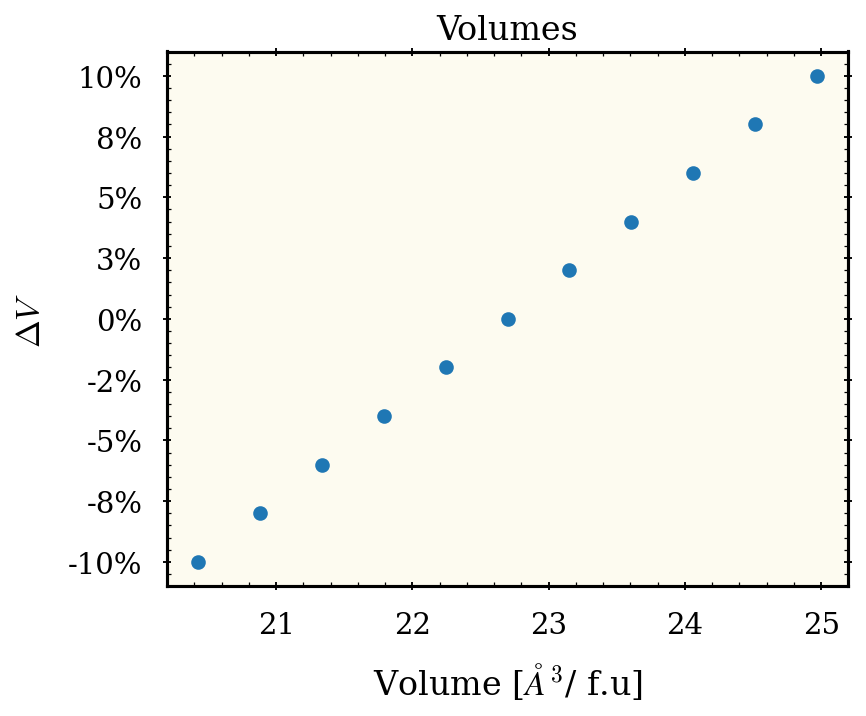

In [216]:
from matplotlib.ticker import FuncFormatter

fu = 2 # formula-unit
volumes = [(atom.get_volume() / fu ) for atom in deformed_structures.values()]

fig, ax = plt.subplots(dpi=150)

ax.set_title("Volumes")
ax.set_ylabel(r"$\Delta V$")
ax.set_xlabel(r"Volume [$\AA^{3}$/ f.u]")

ax.tick_params(direction='inout')
ax.tick_params(which="minor", length=2.0, width=0.6)
ax.tick_params(which="major", length=4.0, width=0.9)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x*100:.0f}%"))

ax.scatter(y=volume_factors-1, x=volumes)

plt.show()

Writing lammps-data files using **ASE**

In [209]:
for factor, atoms in deformed_structures.items():
    filename =  f"lammps_v_{factor:.2f}.data" # lammps-data filename
    
    io.write(filename, atoms, format='lammps-data', specorder=["Zn", "O"], atom_style='atomic')
    

In [210]:
print(*volumes, sep="\n")

20.428951120570066
20.882927812138284
21.336904503706503
21.790881195274732
22.244857886842947
22.698834578411173
23.1528112699794
23.606787961547628
24.06076465311584
24.51474134468406
24.968718036252298


In [211]:
! ls

data.txt	    log_lammps_v_0.90.txt  pw.v0.90.out  pw.v1.04.out
in.lmp		    log_lammps_v_0.92.txt  pw.v0.92.in	 pw.v1.06.in
lammps_v_0.90.data  log_lammps_v_0.94.txt  pw.v0.92.out  pw.v1.06.out
lammps_v_0.92.data  log_lammps_v_0.96.txt  pw.v0.94.in	 pw.v1.08.in
lammps_v_0.94.data  log_lammps_v_0.98.txt  pw.v0.94.out  pw.v1.08.out
lammps_v_0.96.data  log_lammps_v_1.00.txt  pw.v0.96.in	 pw.v1.10.in
lammps_v_0.98.data  log_lammps_v_1.02.txt  pw.v0.96.out  pw.v1.10.out
lammps_v_1.00.data  log_lammps_v_1.04.txt  pw.v0.98.in	 quantum_espresso_lda
lammps_v_1.02.data  log_lammps_v_1.06.txt  pw.v0.98.out  README.md
lammps_v_1.04.data  log_lammps_v_1.08.txt  pw.v1.00.in	 run.sh
lammps_v_1.06.data  log_lammps_v_1.10.txt  pw.v1.00.out  temp.lammps
lammps_v_1.08.data  murnaghan_fit.ipynb    pw.v1.02.in	 Zn.pytorch.nn
lammps_v_1.10.data  O.pytorch.nn	   pw.v1.02.out
log.lammps	    pw.v0.90.in		   pw.v1.04.in


In [ ]:
%%bash
for f in $(ls log_lammps_v_*.txt); do
    energy=$(grep -A 1 "Step " "$f" | tail -n 1 | awk '{print $3}')
    echo "$f, $energy" >> data.txt
done

In [212]:
! cat data.txt

log_lammps_v_0.90.txt, -12269.802
log_lammps_v_0.92.txt, -12269.912
log_lammps_v_0.94.txt, -12269.997
log_lammps_v_0.96.txt, -12270.054
log_lammps_v_0.98.txt, -12270.085
log_lammps_v_1.00.txt, -12270.097
log_lammps_v_1.02.txt, -12270.088
log_lammps_v_1.04.txt, -12270.061
log_lammps_v_1.06.txt, -12270.017
log_lammps_v_1.08.txt, -12269.96
log_lammps_v_1.10.txt, -12269.895


## ÆNET-LAMMPS - Birch-Murnaghan Fit

In [214]:
from ase.eos import EquationOfState
from ase.units import kJ

In [217]:
energies = np.loadtxt(fname='data.txt', delimiter=',', usecols=(1,))
energies = energies / fu

print("ENERGY:")
print(*energies, sep="\n")

print()

print("VOLUMES:")
print(*volumes, sep="\n")


ENERGY:
-6134.901
-6134.956
-6134.9985
-6135.027
-6135.0425
-6135.0485
-6135.044
-6135.0305
-6135.0085
-6134.98
-6134.9475

VOLUMES:
20.428951120570066
20.882927812138284
21.336904503706503
21.790881195274732
22.244857886842947
22.698834578411173
23.1528112699794
23.606787961547628
24.06076465311584
24.51474134468406
24.968718036252298


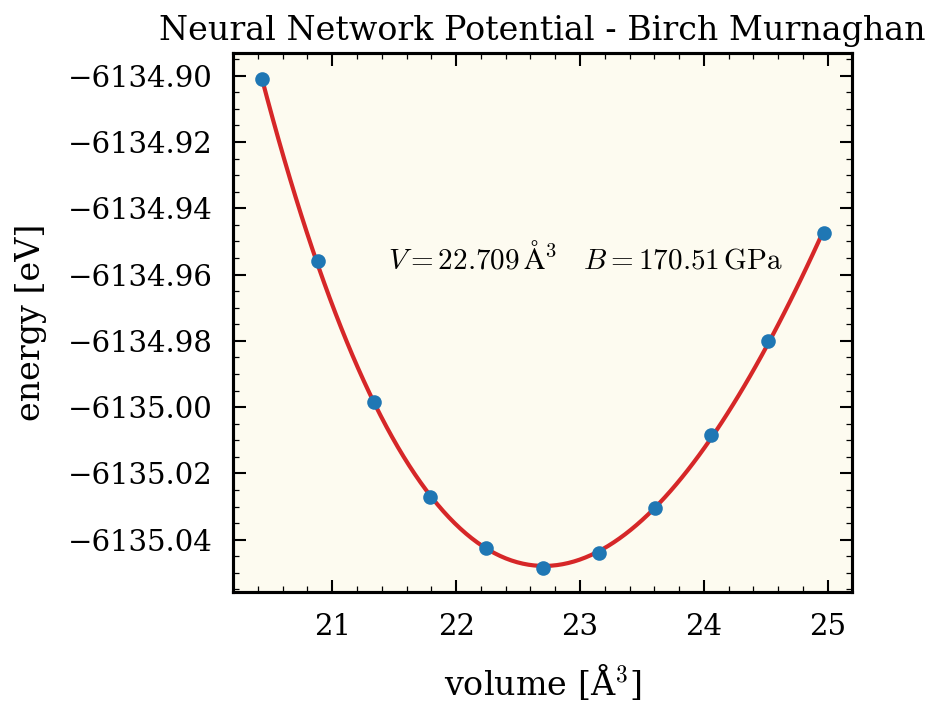

In [219]:
eos = EquationOfState(volumes, energies, eos="murnaghan")
v0, e0, B = eos.fit()
B_GPa = B / kJ * 1.0e24

# ---
# Plot

fig, ax = plt.subplots()
ax = eos.plot(show=False, ax=ax)
ax.set_title("Neural Network Potential - Birch Murnaghan")
ax.text(
    transform=ax.transAxes,
    x=0.25,
    y=0.6, 
    s=rf"$V = {v0:.3f}\,\mathrm{{\AA^3}}\quad B = {B_GPa:.2f}\,\mathrm{{GPa}}$",
)
plt.show()


## Equation of State using Quantum ESPRESSO

In [175]:
QE_CONFIG = {
    "input_data": {
        "control": {
            "calculation": "scf",
            "prefix": "ZnO_LDA",
            "pseudo_dir": "/home/jvc/ZnO_database/pseudos/ppdojo_LDA/",
            "outdir": "./",
            "disk_io": "none",
            "verbosity": "high",
            "tprnfor": True,
            "tstress": True,
        },
        "system": {"ibrav": 0, "ecutwfc": 80, "ecutrho": 320, "occupations": "fixed"},
        "electrons": {"conv_thr": 1e-8, "mixing_beta": 0.3},
    },
    "pseudos": {
        "Zn": "Zn_pseudo-dojo_NC_SR_LDA.upf",
        "O": "O_pseudo-dojo_NC_SR_LDA.upf",
    },
}

In [176]:
! mkdir quantum_espresso_lda

In [ ]:
# io.write(
#     "teste.pw.in",
#     deformed_structures[0.9],
#     format='espresso-in',
#     input_data=QE_CONFIG["input_data"],
#     pseudopotentials=QE_CONFIG["pseudos"],
#     kpts=(6, 6, 4),
#     koffset=(0, 0, 0),
#     crystal_coordinates=True,
# )

In [182]:
for factor, atom_obj in deformed_structures.items():
    filename = f'pw.v{factor:.2f}.in'
    io.write(
        filename,
        atom_obj,
        format='espresso-in',
        input_data=QE_CONFIG["input_data"],
        pseudopotentials=QE_CONFIG["pseudos"],
        kpts=(6, 6, 4),
        koffset=(0, 0, 0),
        crystal_coordinates=True,
    )



Run QE inputs with:

```bash
for f in pw.*.in;do
    mpirun -np 16 pw.x < "$f" > "${f%.in}.out"
done
```


In [188]:
dft_atoms = [io.read(f) for f in Path().glob("pw.*.out")]


In [190]:
fu = 2
dft_volumes = [atom.get_volume() / fu for atom in dft_atoms]
dft_energies = [atom.get_total_energy() / fu for atom in dft_atoms]

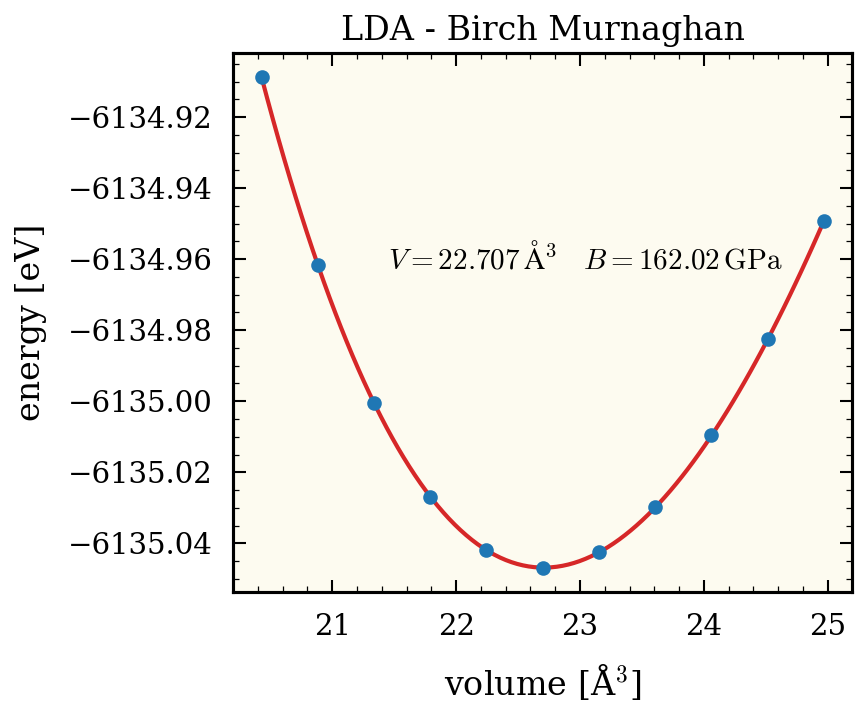

In [192]:
eos = EquationOfState(dft_volumes, dft_energies, eos="murnaghan")
v0, e0, B = eos.fit()
B_GPa = B / kJ * 1.0e24

# ---
# Plot

fig, ax = plt.subplots()
ax = eos.plot(show=False, ax=ax)
ax.set_title("LDA - Birch Murnaghan")
ax.text(
    transform=ax.transAxes,
    x=0.25,
    y=0.6, 
    s=rf"$V = {v0:.3f}\,\mathrm{{\AA^3}}\quad B = {B_GPa:.2f}\,\mathrm{{GPa}}$",
)
plt.show()